In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Restaurant Tipping Behavior Analysis

## Statistical Modeling with Python

This project analyzes restaurant tipping behavior using the Tips dataset.

The analysis includes:

- Exploratory Data Analysis
- Descriptive Statistics
- Hypothesis Testing
- Multiple Linear Regression
- Regression Diagnostics

In [7]:
df = pd.read_csv("data/tips.csv")

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


# Part 1: Exploratory Data Analysis and Hypothesis Testing

## 1. Dataset Overview

In [9]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

df.info()

df.isnull().sum()

df.duplicated().sum()



Dataset Shape: (244, 7)

Columns:
['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']
<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    str    
 3   smoker      244 non-null    str    
 4   day         244 non-null    str    
 5   time        244 non-null    str    
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), str(4)
memory usage: 13.5 KB


np.int64(1)

## 2. Descriptive Statistics

In [10]:
df.describe()

numerical_columns = ["total_bill", "tip", "size"]

descriptive_stats = pd.DataFrame({
    "Mean": df[numerical_columns].mean(),
    "Median": df[numerical_columns].median(),
    "Standard Deviation": df[numerical_columns].std(),
    "IQR": df[numerical_columns].quantile(0.75) - df[numerical_columns].quantile(0.25),
    "Skewness": df[numerical_columns].skew(),
    "Kurtosis": df[numerical_columns].kurt()
})

descriptive_stats.round(3)

,Mean,Median,Standard Deviation,IQR,Skewness,Kurtosis
total_bill,19.786,17.795,8.902,10.780,1.133,1.218
tip,2.998,2.900,1.384,1.562,1.465,3.648
size,2.570,2.000,0.951,1.000,1.448,1.732


## 3. Distribution Analysis

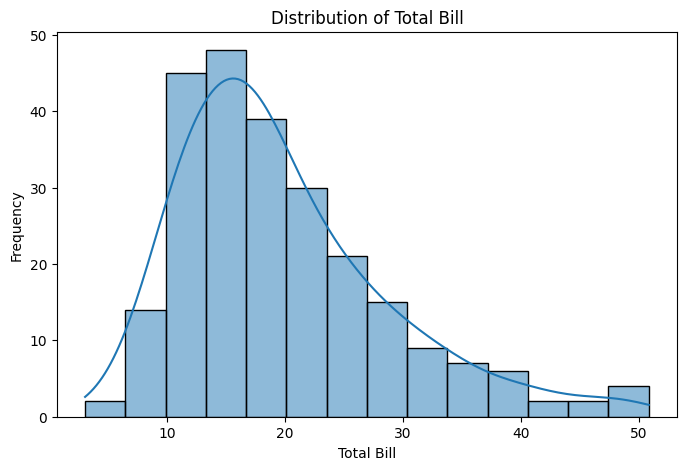

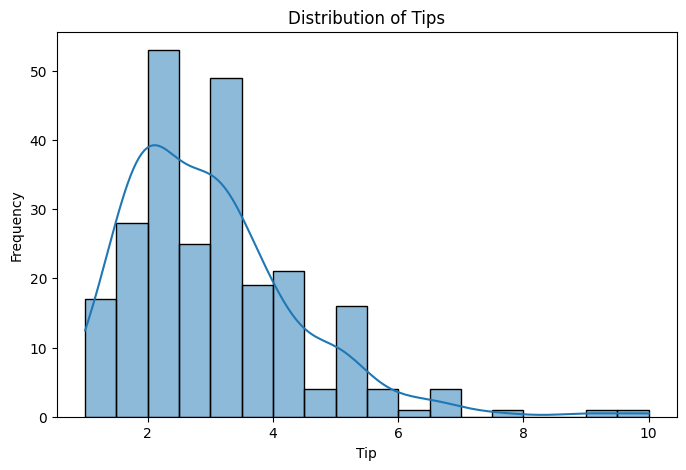

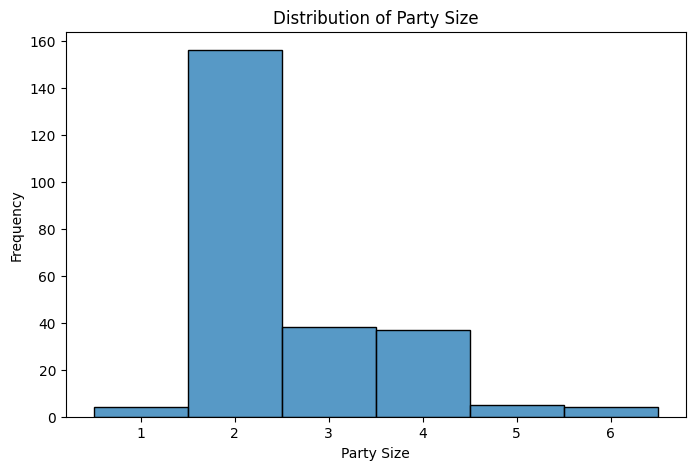

In [12]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="total_bill",
    kde=True
)

plt.title("Distribution of Total Bill")
plt.xlabel("Total Bill")
plt.ylabel("Frequency")

plt.show()


plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="tip",
    kde=True
)

plt.title("Distribution of Tips")
plt.xlabel("Tip")
plt.ylabel("Frequency")

plt.show()


plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="size",
    discrete=True
)

plt.title("Distribution of Party Size")
plt.xlabel("Party Size")
plt.ylabel("Frequency")

plt.show()

## 4. Bivariate Analysis

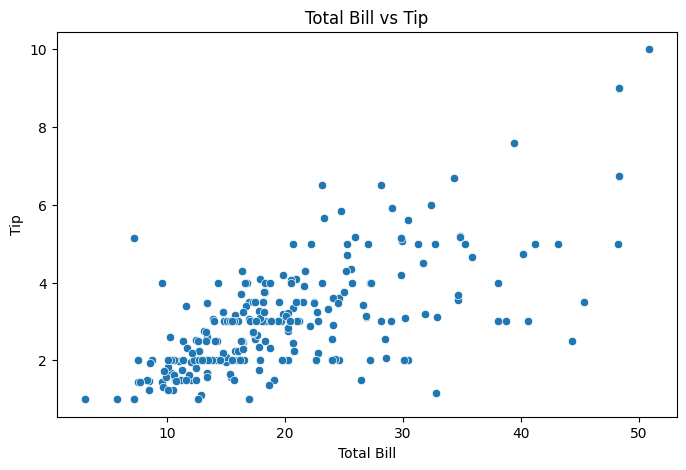

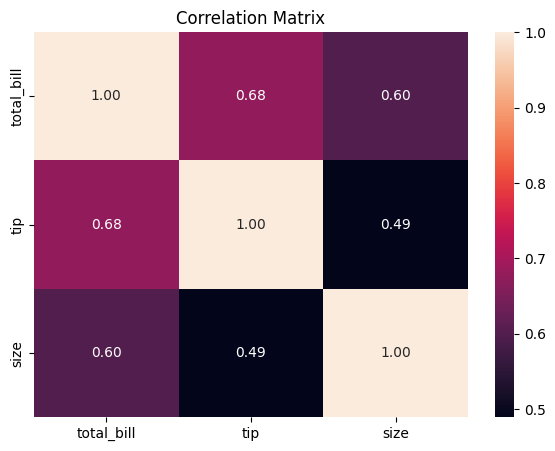

In [13]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="total_bill",
    y="tip"
)

plt.title("Total Bill vs Tip")
plt.xlabel("Total Bill")
plt.ylabel("Tip")

plt.show()

correlation_matrix = df[
    ["total_bill", "tip", "size"]
].corr()

correlation_matrix

plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

## 5. Hypothesis Test 1

### Smokers vs Non-Smokers

H0: There is no significant difference in tips between smokers and non-smokers.

H1: There is a significant difference in tips between smokers and non-smokers.

Significance Level: α = 0.05

In [14]:
smoker_tips = df[
    df["smoker"] == "Yes"
]["tip"]

non_smoker_tips = df[
    df["smoker"] == "No"
]["tip"]

print("Smokers:", len(smoker_tips))
print("Non-Smokers:", len(non_smoker_tips))

Smokers: 93
Non-Smokers: 151


### Normality Test — Shapiro-Wilk

In [15]:
shapiro_smoker = stats.shapiro(smoker_tips)
shapiro_non_smoker = stats.shapiro(non_smoker_tips)

print("Smokers")
print("Statistic:", shapiro_smoker.statistic)
print("p-value:", shapiro_smoker.pvalue)

print("\nNon-Smokers")
print("Statistic:", shapiro_non_smoker.statistic)
print("p-value:", shapiro_non_smoker.pvalue)

Smokers
Statistic: 0.8788249661085323
p-value: 3.612564299352561e-07

Non-Smokers
Statistic: 0.9040014583128897
p-value: 2.0587577392218212e-08


### Equal Variance Test — Levene's Test

In [16]:
levene_result = stats.levene(
    smoker_tips,
    non_smoker_tips
)

print("Statistic:", levene_result.statistic)
print("p-value:", levene_result.pvalue)

Statistic: 0.02051159105706963
p-value: 0.8862366542563253


### Final Two-Group Test

In [17]:
if (
    shapiro_smoker.pvalue > 0.05
    and shapiro_non_smoker.pvalue > 0.05
):

    equal_variance = levene_result.pvalue > 0.05

    result = stats.ttest_ind(
        smoker_tips,
        non_smoker_tips,
        equal_var=equal_variance
    )

    test_name = "Independent Two-Sample t-test"

else:

    result = stats.mannwhitneyu(
        smoker_tips,
        non_smoker_tips,
        alternative="two-sided"
    )

    test_name = "Mann-Whitney U Test"


print("Test Used:", test_name)
print("Statistic:", result.statistic)
print("p-value:", result.pvalue)

if result.pvalue < 0.05:
    print("Conclusion: Reject H0")
else:
    print("Conclusion: Fail to Reject H0")

Test Used: Mann-Whitney U Test
Statistic: 7163.0
p-value: 0.7919240198382322
Conclusion: Fail to Reject H0


## 6. Hypothesis Test 2 — One-Way ANOVA

H0: The average tip is the same across all days.

H1: At least one day has a significantly different average tip.

Significance Level: α = 0.05

In [18]:
day_groups = [
    df[df["day"] == day]["tip"]
    for day in df["day"].unique()
]

anova_result = stats.f_oneway(*day_groups)

print("F-Statistic:", anova_result.statistic)
print("p-value:", anova_result.pvalue)

if anova_result.pvalue < 0.05:
    print("Conclusion: Reject H0")
else:
    print("Conclusion: Fail to Reject H0")

df.groupby(
    "day"
)["tip"].agg([
    "count",
    "mean",
    "median",
    "std"
])

F-Statistic: 1.6723551980998699
p-value: 0.17358855530405823
Conclusion: Fail to Reject H0


,count,mean,median,std
day,,,,
Fri,19,2.734737,3.000,1.019577
Sat,87,2.993103,2.750,1.631014
Sun,76,3.255132,3.150,1.234880
Thur,62,2.771452,2.305,1.240223


# Part 2: Statistical Modeling and Diagnostic Checks

## 7. Multiple Linear Regression

In [24]:
model_df = pd.get_dummies(
    df[
        [
            "tip",
            "total_bill",
            "size",
            "sex",
            "smoker",
            "time"
        ]
    ],
    drop_first=True,
    dtype=int
)

model_df.head()


X = model_df.drop(
    "tip",
    axis=1
)

y = model_df["tip"]

X = sm.add_constant(X)

model = sm.OLS(
    y,
    X
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.469
Model:                            OLS   Adj. R-squared:                  0.458
Method:                 Least Squares   F-statistic:                     42.00
Date:                Mon, 14 Sep 2026   Prob (F-statistic):           6.57e-31
Time:                        03:06:07   Log-Likelihood:                -347.78
No. Observations:                 244   AIC:                             707.6
Df Residuals:                     238   BIC:                             728.5
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.6083      0.240      2.531      

## 8. Regression Coefficients and Confidence Intervals

In [25]:
regression_results = pd.DataFrame({
    "Coefficient": model.params,
    "p-value": model.pvalues,
    "CI Lower": model.conf_int()[0],
    "CI Upper": model.conf_int()[1]
})

regression_results.round(4)

print(
    "R-squared:",
    round(model.rsquared, 4)
)

print(
    "Adjusted R-squared:",
    round(model.rsquared_adj, 4)
)

R-squared: 0.4688
Adjusted R-squared: 0.4576


## 9. Regression Diagnostic Checks

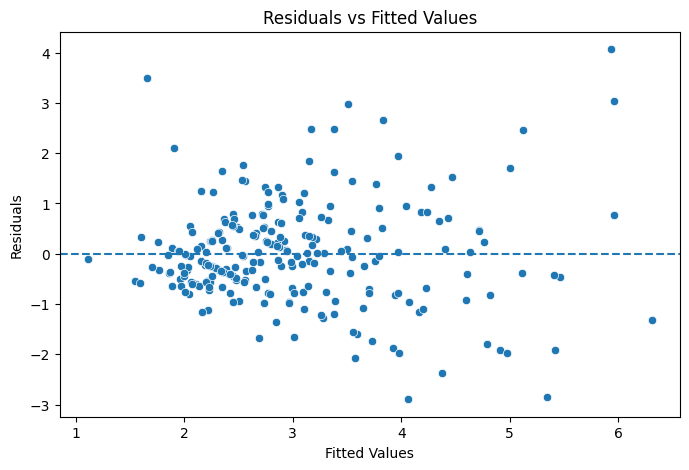

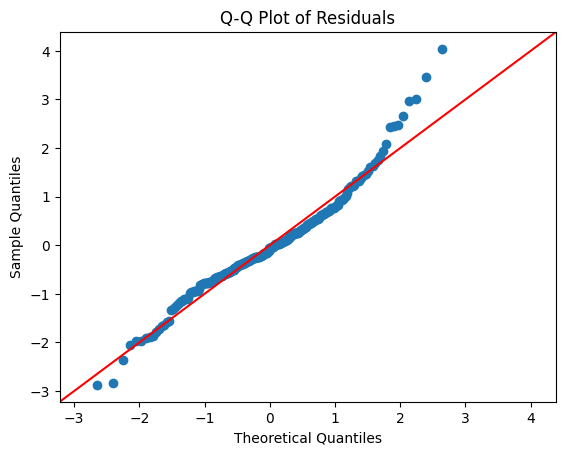

Jarque-Bera Statistic: 50.39869098599783
p-value: 1.1377931238415956e-11


In [26]:
fitted_values = model.fittedvalues
residuals = model.resid

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=fitted_values,
    y=residuals
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")

plt.show()

sm.qqplot(
    residuals,
    line="45",
    fit=True
)

plt.title(
    "Q-Q Plot of Residuals"
)

plt.show()

jb_result = stats.jarque_bera(
    residuals
)

print(
    "Jarque-Bera Statistic:",
    jb_result.statistic
)

print(
    "p-value:",
    jb_result.pvalue
)

## 10. Multicollinearity — Variance Inflation Factor

In [27]:
continuous_predictors = df[
    ["total_bill", "size"]
].copy()

continuous_predictors = sm.add_constant(
    continuous_predictors
)

vif_data = pd.DataFrame()

vif_data["Variable"] = (
    continuous_predictors.columns
)

vif_data["VIF"] = [
    variance_inflation_factor(
        continuous_predictors.values,
        i
    )
    for i in range(
        continuous_predictors.shape[1]
    )
]

vif_data

,Variable,VIF
0,const,1.000000
1,total_bill,1.557586
2,size,1.557586
